# Import the necesary libraries

In [32]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Load the dataset into the notebook

In [33]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gpiosenka/cats-in-the-wild-image-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/gpiosenka/cats-in-the-wild-image-classification


# Set random seeds

In [34]:
SEED = 30

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'Random seed set to : {SEED}')

Random seed set to : 30


# Set global hyperparameters.

In [35]:
DATASET_DIR = path
IMG_SIZE = (224, 224)
BATCH_SIZE = 25
EPOCHS = 50
LR = 1e-4
ANIMAL_CLASS = ['TIGER', 'CLOUDED LEOPARD', 'SNOW LEOPARD', 'AFRICAN LEOPARD']

# Load the training dataset 

In [36]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    f'{DATASET_DIR}/train/',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle= True,
    class_names = ANIMAL_CLASS
)

Found 933 files belonging to 4 classes.


# Load the test dataset

In [37]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    f'{DATASET_DIR}/test/',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle= False,
    class_names = ANIMAL_CLASS
)

Found 20 files belonging to 4 classes.


# Load the validation dataset

In [38]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    f'{DATASET_DIR}/valid/',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle= False,
    class_names = ANIMAL_CLASS
)

Found 20 files belonging to 4 classes.


# Get class names and number of classes

In [39]:
CLASS_NAMES = train_ds.class_names
num_classes= len(CLASS_NAMES)
print(f'Classes ({num_classes}): {CLASS_NAMES}')

Classes (4): ['TIGER', 'CLOUDED LEOPARD', 'SNOW LEOPARD', 'AFRICAN LEOPARD']


# Visualise dataset samples

In [40]:
for images, labels in train_ds.take(1):
    fixed_images = images.numpy()
    fixed_labels = labels.numpy()

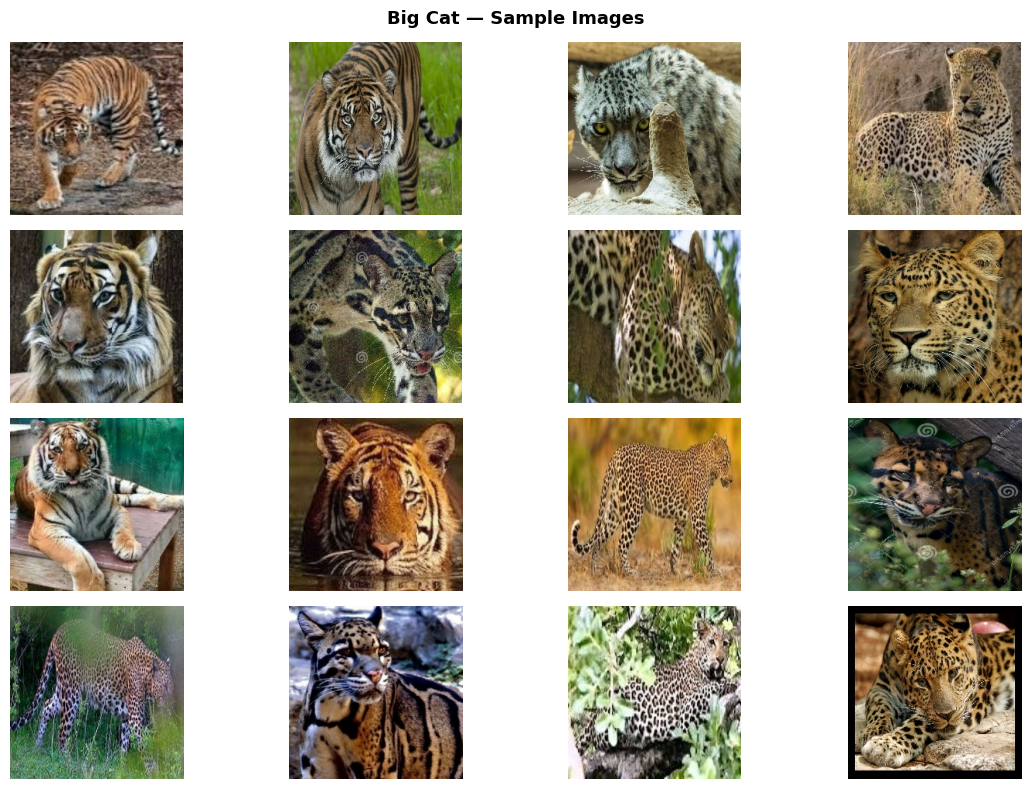

In [41]:
plt.figure(figsize=(12, 8))
for i in range(min(16, len(fixed_images))):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(fixed_images[i].astype('uint8'))
    plt.axis('off')
plt.suptitle('Big Cat — Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('big_cat_sample.png', dpi=120, bbox_inches='tight')
plt.show()

# Optimise the data pipeline.

In [42]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = (train_ds.cache().shuffle(250).prefetch(buffer_size=AUTOTUNE))
val_ds = (val_ds.cache().prefetch(buffer_size=AUTOTUNE))
test_ds = (test_ds.cache().prefetch(buffer_size=AUTOTUNE))

 # Define the data augmentation pipeline.

In [43]:
# Augmentation for training only
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
], name= 'data_augumentation')

# Visualise augmentation effects on one image

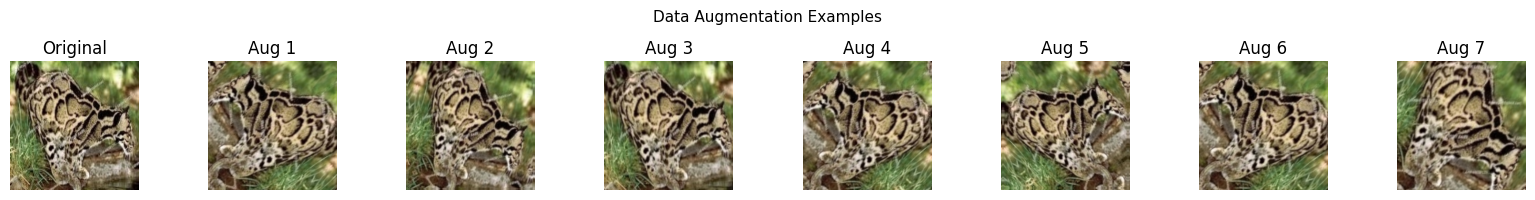

In [44]:
for images, _ in train_ds.take(1):
    sample = images[0:1] # shape (1, 224, 224, 3)
    break

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
axes[0].imshow(sample[0].numpy().astype('uint8'))
axes[0].set_title('Original'); axes[0].axis('off')

for i in range(1, 8):
    aug_img = data_augmentation(sample,training=True)[0].numpy().astype('uint8')
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Aug {i}')
    axes[i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=11)
plt.tight_layout()
plt.show()

# Define shared callbacks and utilities.

In [45]:
os.makedirs('models', exist_ok=True)
def make_callbacks(name):
    """Return a fresh set of callbacks for each model."""
    return [ tf.keras.callbacks.ModelCheckpoint(
        filepath=f'models/{name}_best.keras',
        monitor='val_accuracy', save_best_only=True,
        ),
        tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=8,
        restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.3,
        patience=4, min_lr=1e-7, verbose=1
        ),
        ]
def plot_learning_curves(history, title='Learning Curves'):
    """Plot accuracy and loss curves side-by-side."""
    acc= history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2,linestyle='--')
    plt.legend()
    plt.title(f'{title} — Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2,linestyle='--')
    plt.legend()
    plt.title(f'{title} — Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

def evaluate_model(model, dataset, class_names, title='Model',results_dir='./'):

    y_true, y_pred, y_prob = [], [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        # multiclass prediction (softmax -> argmax)
        preds = np.argmax(probs, axis=1)
        y_prob.append(probs)
        y_pred.append(preds)
        y_true.append(labels.numpy())
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_prob = np.concatenate(y_prob)
    
    print("Unique predicted classes:", np.unique(y_pred))
    print("Unique true classes:", np.unique(y_true))
    print("Prediction distribution:", np.bincount(y_pred))
    print("True distribution:", np.bincount(y_true))
    
    print(f"\n{title}")
    print(f'Accuracy : {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision : {precision_score(y_true, y_pred,average="weighted", zero_division=0):.4f}')
    print(f'Recall: {recall_score(y_true, y_pred,average="weighted", zero_division=0):.4f}')
    print(f'F1-Score : {f1_score(y_true, y_pred, average="weighted", zero_division=0):.4f}')

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names,digits=4))
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(15, 12))
    sns.heatmap(cm, cmap='Blues', cbar=False, annot=True, fmt='',xticklabels=class_names, yticklabels=class_names,
    annot_kws={'fontsize': 9, 'fontweight': 'bold'})
    plt.title(f'{title} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return accuracy_score(y_true, y_pred)
print('Callbacks and utility functions defined.')

Callbacks and utility functions defined.


# Build the Custom CNN Architecture

In [46]:
INPUT_SHAPE = (IMG_SIZE[0],IMG_SIZE[1] , 3)
OUTPUTS = num_classes
def build_custom_cnn(input_shape, augmentation):
   
    inputs = tf.keras.Input(shape=input_shape)
    x = augmentation(inputs)
   
    x = tf.keras.layers.Rescaling(1.0 / 255)(x)
    
    # Block 1: 32 filters
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    
    # Block 2: 64 filters
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    
    # Block 3: 128 filters
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    
    # Classification Head
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    
    outputs = tf.keras.layers.Dense(OUTPUTS, activation='softmax')(x)
    return tf.keras.Model(inputs, outputs, name='custom_cnn')
    
cnn_model = build_custom_cnn(INPUT_SHAPE, data_augmentation)
cnn_model.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augumentation (Sequential) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             

 Total params: 322,852 (1.23 MB)

 Trainable params: 321,956 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)

# Compile the custom CNN mdel.

In [47]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

# Train the model and save the training history

In [48]:
cnn_history = cnn_model.fit(
    train_ds, validation_data=val_ds,epochs=EPOCHS,
    callbacks=make_callbacks('custom_cnn'), verbose=1)

Epoch 1/50


E0000 00:00:1785164191.027631      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/custom_cnn_1/dropout_5_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 123ms/step - accuracy: 0.4459 - loss: 1.2612 - val_accuracy: 0.2500 - val_loss: 1.4100 - learning_rate: 1.0000e-04
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.5338 - loss: 1.0992 - val_accuracy: 0.2500 - val_loss: 1.4447 - learning_rate: 1.0000e-04
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.5734 - loss: 1.0126 - val_accuracy: 0.2500 - val_loss: 1.4730 - learning_rate: 1.0000e-04
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.6367 - loss: 0.9438 - val_accuracy: 0.2500 - val_loss: 1.5152 - learning_rate: 1.0000e-04
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.6162 - loss: 0.9600
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.6259 - loss: 0.9455 - val_accuracy: 0.2500 - val_loss: 1.7019 - learning_rate: 1.0000e-04
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.6624 - loss: 

# Evaluate the Custom CNN on validation dataset

In [49]:
cnn_val_loss, cnn_val_acc = cnn_model.evaluate(val_ds, verbose=0)
print(f'Custom CNN -> val_loss: {cnn_val_loss:.4f}')
print(f'val_accuracy: {cnn_val_acc:.4f}')

Custom CNN -> val_loss: 1.4100
val_accuracy: 0.2500


# Visualise the Learning curves for the Custom CNN

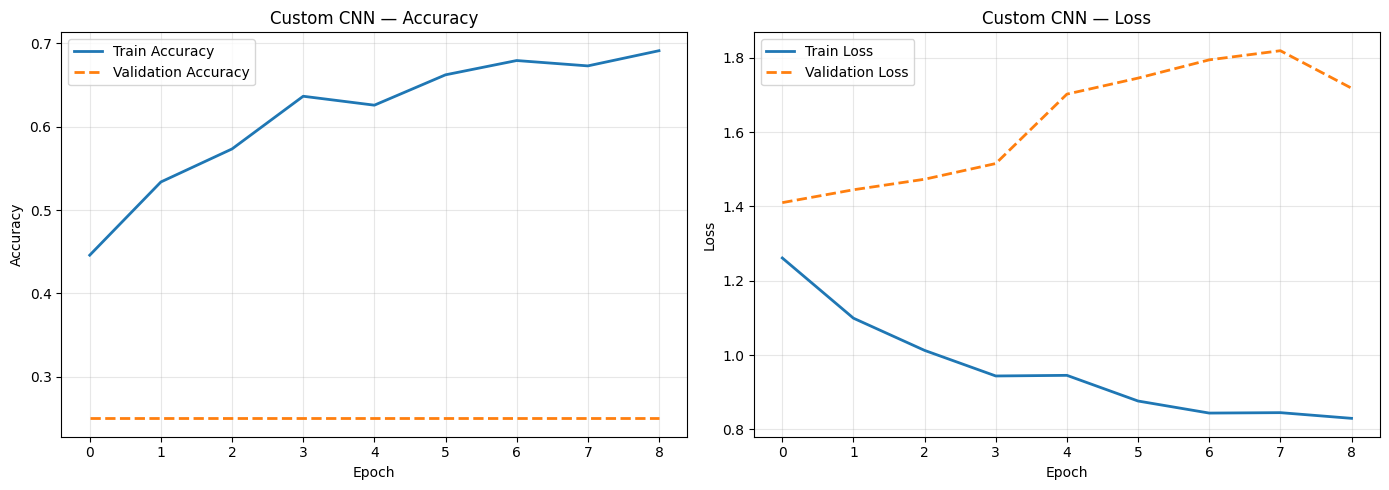

In [50]:
plot_learning_curves(cnn_history, 'Custom CNN')

# Evaluate the Custom CNN on test dataset

In [51]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(test_ds, verbose=0)
print(f'Custom CNN -> test_loss: {cnn_val_loss:.4f}')
print(f'test_accuracy: {cnn_test_acc:.4f}')

Custom CNN -> test_loss: 1.4100
test_accuracy: 0.2500


# Evaluate CNN model

Unique predicted classes: [0]
Unique true classes: [0 1 2 3]
Prediction distribution: [20]
True distribution: [5 5 5 5]

Model
Accuracy : 0.2500
Precision : 0.0625
Recall: 0.2500
F1-Score : 0.1000

Classification Report:
                 precision    recall  f1-score   support

          TIGER     0.2500    1.0000    0.4000         5
CLOUDED LEOPARD     0.0000    0.0000    0.0000         5
   SNOW LEOPARD     0.0000    0.0000    0.0000         5
AFRICAN LEOPARD     0.0000    0.0000    0.0000         5

       accuracy                         0.2500        20
      macro avg     0.0625    0.2500    0.1000        20
   weighted avg     0.0625    0.2500    0.1000        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


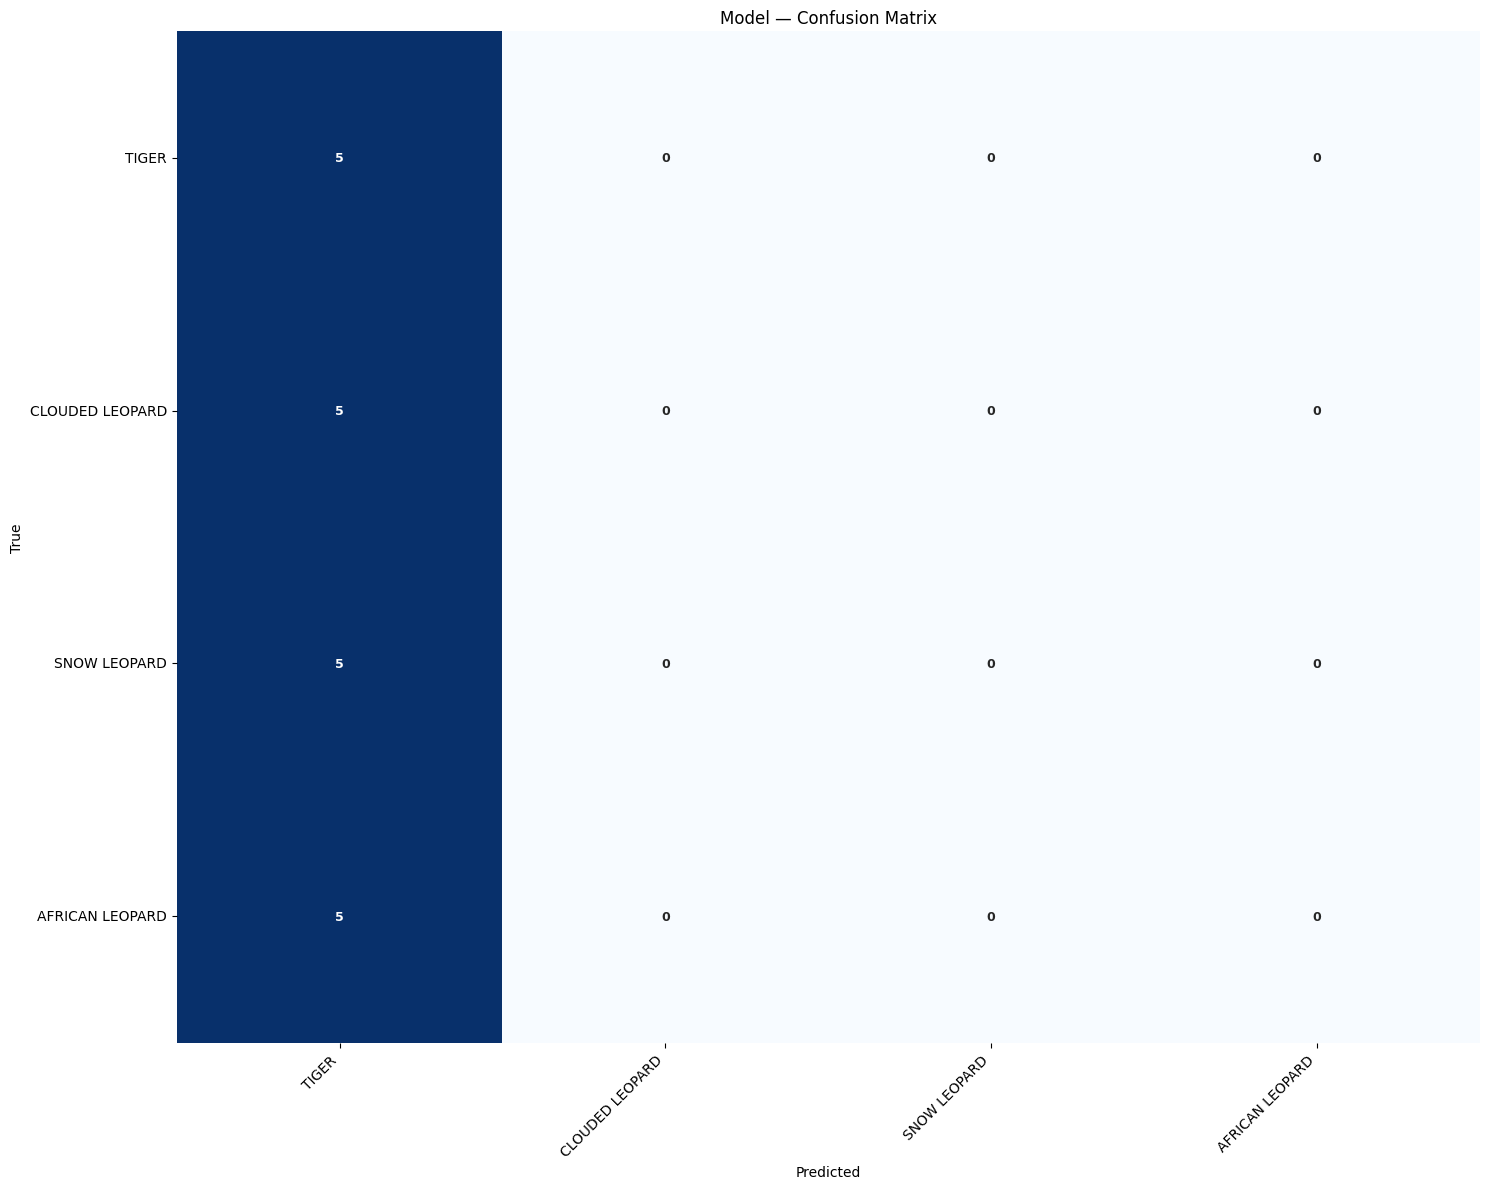

0.25

In [52]:
evaluate_model(cnn_model, test_ds, CLASS_NAMES)

#  Build the Transfer Learning Model (MobileNetV3Small)

In [53]:
def build_transfer_model(input_shape, augmentation,backbone='mobilenetv3small'):
   
    if backbone == 'mobilenetv3small':
        base_model = tf.keras.applications.MobileNetV3Small(
            weights='imagenet',
            input_shape=input_shape,
            include_top=False,
        )
        preprocess_fn = tf.keras.applications.mobilenet_v3.preprocess_input
        model_name= 'mobilenetv3small_transfer'
    
    else:
    
        # Fallback: MobileNetV2
        base_model = tf.keras.applications.MobileNetV2(
        weights='imagenet',
        input_shape=input_shape,
        include_top=False,
        )
        preprocess_fn = tf.keras.applications.mobilenet_v2.preprocess_input
        model_name= 'mobilenetv2_transfer'
    
    # Freeze all base layers for feature extraction (no training)
    base_model.trainable = False
    print(f'Base model: {base_model.name}')
    print(f'Trainable layers: {sum(1 for l in base_model.layers if l.trainable)} / {len(base_model.layers)}')
    
    # Build the model graph
    inputs = tf.keras.Input(shape=input_shape)
    x = augmentation(inputs)
    x = preprocess_fn(x) # scale pixels to [-1, 1]
    x = base_model(x, training=False)
    # frozen inference mode
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(OUTPUTS, activation='softmax')(x)
    return tf.keras.Model(inputs, outputs, name=model_name), base_model
    
tl_model, base_model = build_transfer_model(INPUT_SHAPE, data_augmentation,backbone='mobilenetv3small')
tl_model.summary()

Base model: MobileNetV3Small
Trainable layers: 0 / 157


Model: "mobilenetv3small_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augumentation (Sequential) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,087,860 (4.15 MB)

 Trainable params: 148,740 (581.02 KB)

 Non-trainable params: 939,120 (3.58 MB)

# Compile Transfer learning model 

In [54]:
TL_LR = 1e-4 # Lower LR for transfer learning head

tl_model.compile(
optimizer=tf.keras.optimizers.Adam(learning_rate=TL_LR),
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)



# Train the model.

In [55]:
tl_history = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=make_callbacks('tl_feature_extraction'),
    verbose=1,
)


Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - accuracy: 0.5145 - loss: 1.1257 - val_accuracy: 0.9500 - val_loss: 0.7064 - learning_rate: 1.0000e-04
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8671 - loss: 0.5846 - val_accuracy: 1.0000 - val_loss: 0.4203 - learning_rate: 1.0000e-04
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9228 - loss: 0.3789 - val_accuracy: 1.0000 - val_loss: 0.2899 - learning_rate: 1.0000e-04
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9378 - loss: 0.2979 - val_accuracy: 1.0000 - val_loss: 0.2242 - learning_rate: 1.0000e-04
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9475 - loss: 0.2350 - val_accuracy: 1.0000 - val_loss: 0.1768 - learning_rate: 1.0000e-04
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9539 - loss: 0.2012 - val_accuracy: 1.0000 - val_loss: 0.1478 - learning_rate: 1.0000e-04
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9668 

# Evaluate the Transfer Learning Model on validation dataset

MobileNetV3 TL -> val_loss: 0.0173
MobileNetV3 TL -> val_accuracy: 1.0000


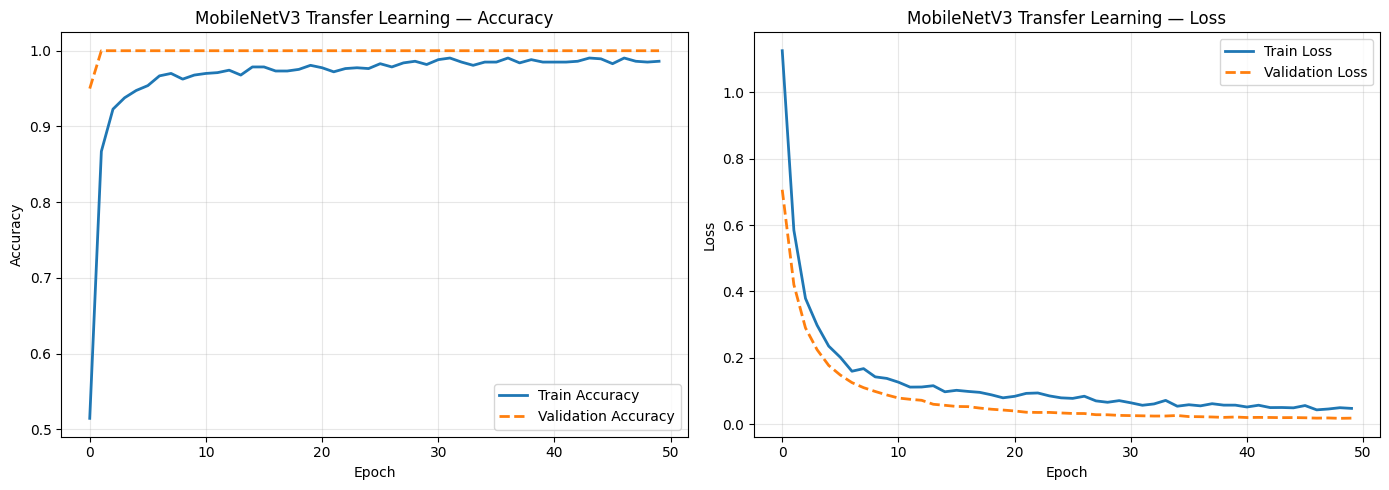

In [56]:
tl_val_loss, tl_val_acc = tl_model.evaluate(val_ds, verbose=0)
print(f'MobileNetV3 TL -> val_loss: {tl_val_loss:.4f}')
print(f'MobileNetV3 TL -> val_accuracy: {tl_val_acc:.4f}')
plot_learning_curves(tl_history, 'MobileNetV3 Transfer Learning')

# Evaluate the Transfer Learning Model on test dataset

MobileNetV3 TL -> val_loss: 0.0118
MobileNetV3 TL -> val_accuracy: 1.0000


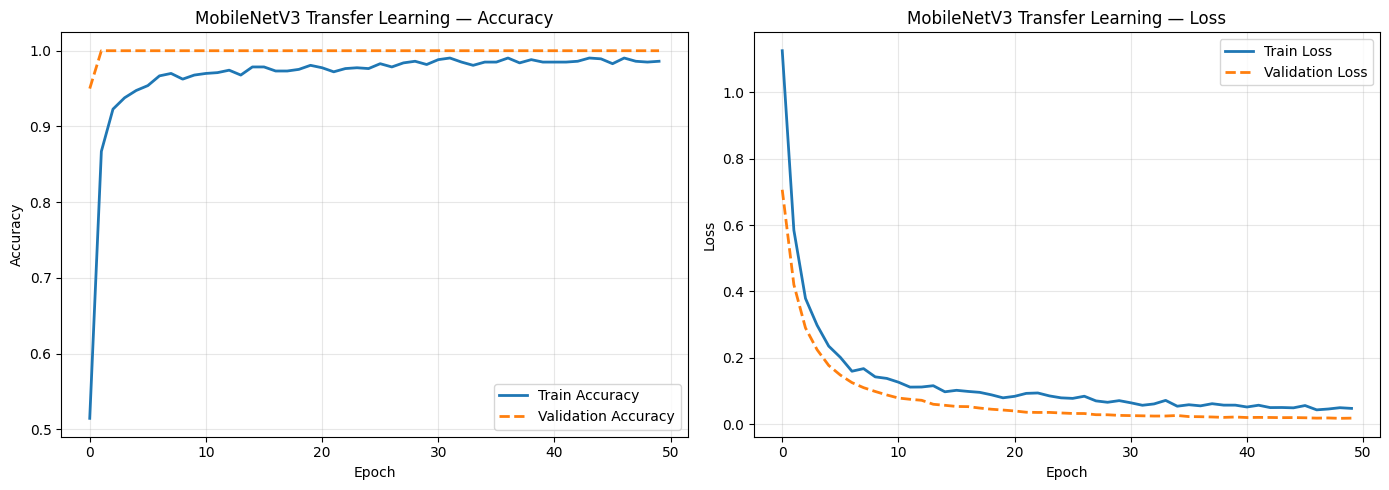

In [57]:
tl_test_loss, tl_test_acc = tl_model.evaluate(test_ds, verbose=0)
print(f'MobileNetV3 TL -> val_loss: {tl_test_loss:.4f}')
print(f'MobileNetV3 TL -> val_accuracy: {tl_test_acc:.4f}')
plot_learning_curves(tl_history, 'MobileNetV3 Transfer Learning')

# Evaluate Transfer Model 

Unique predicted classes: [0 1 2 3]
Unique true classes: [0 1 2 3]
Prediction distribution: [5 5 5 5]
True distribution: [5 5 5 5]

Model
Accuracy : 1.0000
Precision : 1.0000
Recall: 1.0000
F1-Score : 1.0000

Classification Report:
                 precision    recall  f1-score   support

          TIGER     1.0000    1.0000    1.0000         5
CLOUDED LEOPARD     1.0000    1.0000    1.0000         5
   SNOW LEOPARD     1.0000    1.0000    1.0000         5
AFRICAN LEOPARD     1.0000    1.0000    1.0000         5

       accuracy                         1.0000        20
      macro avg     1.0000    1.0000    1.0000        20
   weighted avg     1.0000    1.0000    1.0000        20



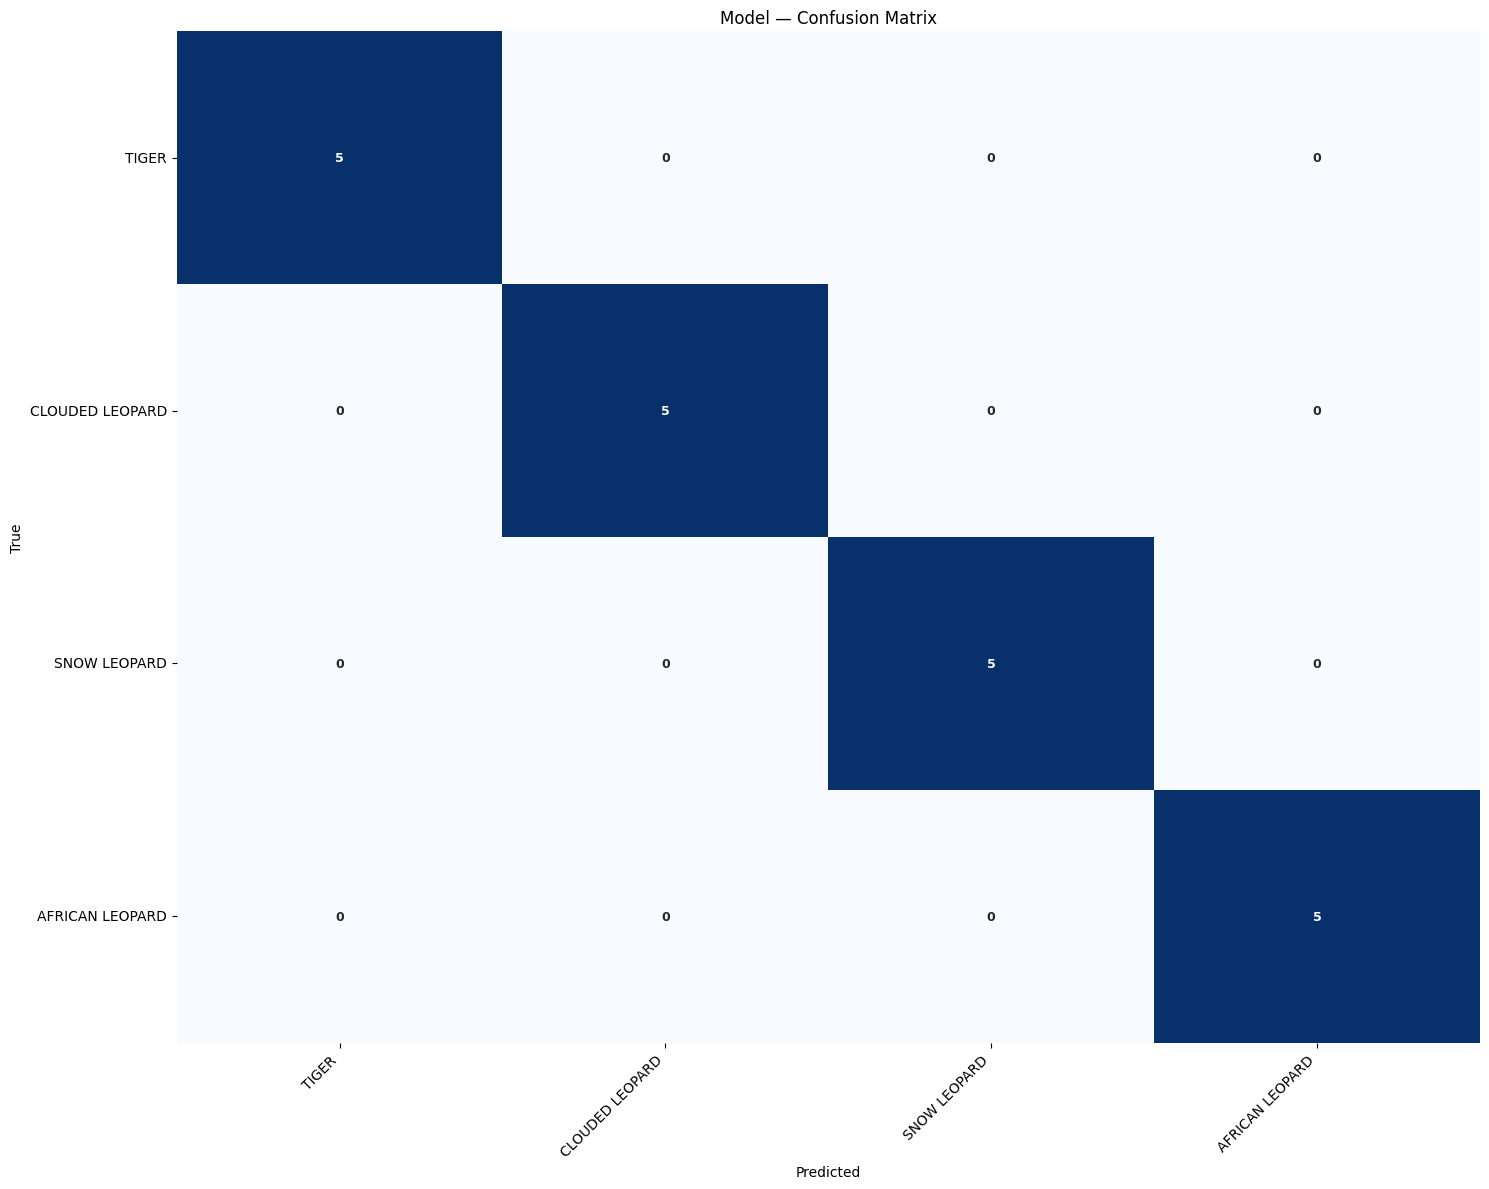

1.0

In [58]:
evaluate_model(tl_model, test_ds, CLASS_NAMES)

# Side-by-side model comparison.

In [59]:
results = {
'Custom CNN': {'acc': cnn_test_acc, 'params': cnn_model.count_params()},
'MobileNetV3 (TL)':{'acc': tl_test_acc,'params':tl_model.count_params()}}

print(f'{"Model":<25} {"Test Acc":>10} {"Params":>14}')
print('-' * 55)
for name, vals in results.items():
    print(f'{name:<25} {vals["acc"]:>10.4f} {vals["params"]:>14,}')

Model                       Test Acc         Params
-------------------------------------------------------
Custom CNN                    0.2500        322,852
MobileNetV3 (TL)              1.0000      1,087,860


# Predict on a new image.

In [60]:
def predict_image(img_path, models_dict, class_names, image_size=IMG_SIZE):
    
    img = tf.keras.utils.load_img(img_path, target_size=image_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) 
    
    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Input Image')
    plt.show()
    
    print(f'\nPredictions for: {img_path}')
    print('-' * 40)
    for name, mdl in models_dict.items():
        prob = mdl.predict(img_array, verbose=0)[0][0]
        label = class_names[int(prob >= 0.5)]
        print(f'{name:<25}: {label} (p={prob:.4f})')

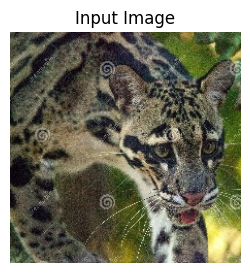


Predictions for: /kaggle/input/datasets/gpiosenka/cats-in-the-wild-image-classification/train/CLOUDED LEOPARD/001.jpg
----------------------------------------
Custom CNN               : TIGER (p=0.3134)
MobileNetV3 TL           : TIGER (p=0.0000)


In [61]:
image_path = '/kaggle/input/datasets/gpiosenka/cats-in-the-wild-image-classification/train/CLOUDED LEOPARD/001.jpg'
predict_image(
    image_path,
    {'Custom CNN': cnn_model, 'MobileNetV3 TL': tl_model},CLASS_NAMES
)

# Save Models 

In [62]:
os.makedirs('models', exist_ok=True)
cnn_model.save('models/custom_cnn.keras')
tl_model.save('models/mobilenetv3_transfer.keras')
print('Models saved:')
print(' models/custom_cnn.keras')
print(' models/mobilenetv3_transfer.keras')

Models saved:
 models/custom_cnn.keras
 models/mobilenetv3_transfer.keras
